# 08 — Final Model Evaluation

## EduPredict — Student Exam Performance Prediction

This notebook performs the **final evaluation on the untouched test set**.

### Rules
- The test set is used only here for final evaluation.
- The model architecture/algorithm was selected using training + validation data in Notebook 07.
- No test-set metric is used to choose the model.
- All reported numbers come from the actual dataset and actual model run.

### Outputs
- Final test RMSE, MAE, R²
- Prediction-vs-actual analysis
- Residual analysis
- Error distribution
- Actual vs predicted plot
- Residual plot
- Final evaluation CSV/JSON
- Saved final model pipeline for later explainability and API work


In [1]:
# 1. Imports and configuration

from pathlib import Path
import json
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

DATA_PATH = Path("../data/processed/student_performance_engineered.csv")
SUMMARY_PATH = Path("../outputs/metrics/model_experiment_summary.json")
SELECTION_PATH = Path("../outputs/metrics/selected_features.json")
PCA_SUMMARY_PATH = Path("../outputs/metrics/pca_summary.json")

METRICS_DIR = Path("../outputs/metrics")
MODELS_DIR = Path("../models")

METRICS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration loaded.")


Configuration loaded.


In [2]:
# 2. Load dataset and experiment summary

df = pd.read_csv(DATA_PATH)

with open(SUMMARY_PATH, "r") as f:
    experiment_summary = json.load(f)

champion_name = experiment_summary["champion_model"]

print("Dataset shape:", df.shape)
print("Validation champion:", champion_name)
print("Validation RMSE:", experiment_summary["champion_validation_rmse"])


Dataset shape: (6606, 22)
Validation champion: LinearRegression
Validation RMSE: 1.8823748328835537


In [3]:
# 3. Recover the exact feature set used in Notebook 07

candidate_features = [
    c for c in df.columns
    if c != "Exam_Score"
]

if SELECTION_PATH.exists():
    with open(SELECTION_PATH, "r") as f:
        selection_info = json.load(f)

    selected_features = [
        c for c in selection_info.get("selected_features", [])
        if c in candidate_features
    ]
else:
    selected_features = []

feature_columns = (
    selected_features
    if selected_features
    else candidate_features
)

print("Number of features:", len(feature_columns))
print(feature_columns)


Number of features: 21
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Study_Attendance_Interaction', 'Study_Sleep_Interaction']


In [4]:
# 4. Recreate the same train / validation / test split

X = df[feature_columns].copy()
y = df["Exam_Score"].copy()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nFinal test set:")
print(y_test.describe())


Training: (4227, 21)
Validation: (1057, 21)
Test: (1322, 21)

Final test set:
count    1322.000000
mean       67.101362
std         3.637888
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max        98.000000
Name: Exam_Score, dtype: float64


In [5]:
# 5. Build the same preprocessing pipeline

numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessor ready.")


Preprocessor ready.


In [6]:
# 6. Recreate the selected champion model

models = {
    "LinearRegression": LinearRegression(),

    "Ridge": Ridge(alpha=1.0),

    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE
    )
}

assert champion_name in models, (
    f"Champion model '{champion_name}' is not available."
)

champion_estimator = models[champion_name]

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", champion_estimator)
])

print("Champion estimator:", champion_name)


Champion estimator: LinearRegression


In [7]:
# 7. Fit champion on training + validation data

# Model selection is already complete.
# Now combine train + validation data before final test evaluation.

X_development = pd.concat(
    [X_train, X_val],
    axis=0
)

y_development = pd.concat(
    [y_train, y_val],
    axis=0
)

print("Development data:", X_development.shape)

final_pipeline.fit(
    X_development,
    y_development
)

print("Final model trained.")


Development data: (5284, 21)
Final model trained.


In [8]:
# 8. Final prediction on untouched test set

test_predictions = final_pipeline.predict(X_test)

rmse = mean_squared_error(
    y_test,
    test_predictions
) ** 0.5

mae = mean_absolute_error(
    y_test,
    test_predictions
)

r2 = r2_score(
    y_test,
    test_predictions
)

print("FINAL TEST PERFORMANCE")
print("=" * 40)
print(f"Model : {champion_name}")
print(f"RMSE  : {rmse:.4f}")
print(f"MAE   : {mae:.4f}")
print(f"R²    : {r2:.4f}")


FINAL TEST PERFORMANCE
Model : LinearRegression
RMSE  : 1.5224
MAE   : 0.4196
R²    : 0.8247


In [9]:
# 9. Build prediction-level evaluation table

evaluation_df = pd.DataFrame({
    "actual_score": y_test.to_numpy(),
    "predicted_score": test_predictions
})

evaluation_df["residual"] = (
    evaluation_df["actual_score"]
    - evaluation_df["predicted_score"]
)

evaluation_df["absolute_error"] = (
    evaluation_df["residual"].abs()
)

evaluation_df["squared_error"] = (
    evaluation_df["residual"] ** 2
)

evaluation_df["prediction_error_pct"] = (
    evaluation_df["absolute_error"]
    / evaluation_df["actual_score"].replace(0, np.nan)
) * 100

display(evaluation_df.head(10))


,actual_score,predicted_score,residual,absolute_error,squared_error,prediction_error_pct
0,66,66.019652,-0.019652,0.019652,0.000386,0.029776
1,66,65.451507,0.548493,0.548493,0.300845,0.831050
2,67,67.602965,-0.602965,0.602965,0.363566,0.899947
3,67,67.570901,-0.570901,0.570901,0.325928,0.852092
4,68,68.030307,-0.030307,0.030307,0.000919,0.044570
5,63,63.317670,-0.317670,0.317670,0.100914,0.504238
6,74,74.072359,-0.072359,0.072359,0.005236,0.097783
7,65,65.131023,-0.131023,0.131023,0.017167,0.201574
8,69,68.936831,0.063169,0.063169,0.003990,0.091549
9,76,75.807082,0.192918,0.192918,0.037218,0.253840


In [10]:
# 10. Error distribution summary

error_summary = evaluation_df[
    ["residual", "absolute_error", "squared_error"]
].describe()

display(error_summary)

print("Mean residual:", evaluation_df["residual"].mean())
print("Median absolute error:", evaluation_df["absolute_error"].median())
print("Maximum absolute error:", evaluation_df["absolute_error"].max())


,residual,absolute_error,squared_error
count,1322.000000,1322.000000,1.322000e+03
mean,-0.097529,0.419646,2.317728e+00
std,1.519857,1.463983,3.798716e+01
min,-1.238561,0.000044,1.942214e-09
25%,-0.455125,0.139764,1.953397e-02
50%,-0.183927,0.290138,8.418024e-02
75%,0.096356,0.491779,2.418471e-01
max,28.982246,28.982246,8.399706e+02


Mean residual: -0.09752936251926084
Median absolute error: 0.2901381315832765
Maximum absolute error: 28.982246275108608


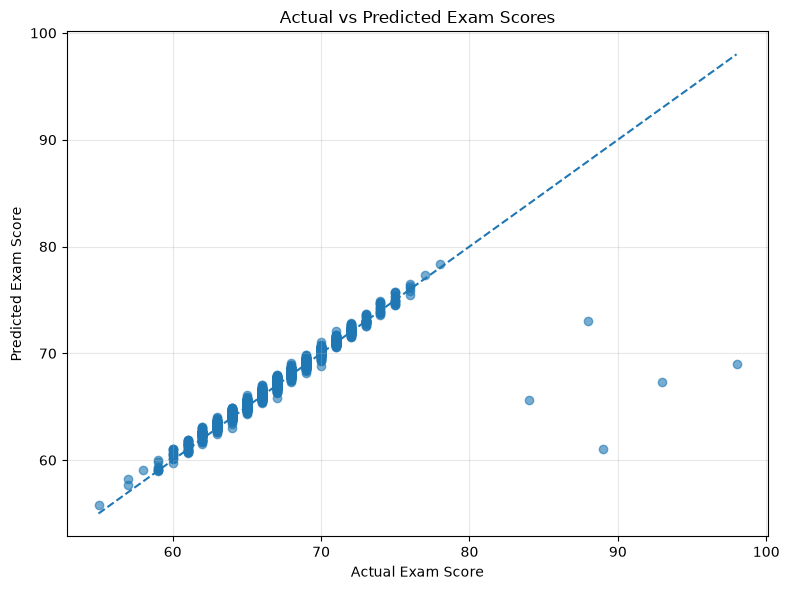

In [11]:
# 11. Actual vs predicted scores

plt.figure(figsize=(8, 6))

plt.scatter(
    evaluation_df["actual_score"],
    evaluation_df["predicted_score"],
    alpha=0.6
)

min_score = min(
    evaluation_df["actual_score"].min(),
    evaluation_df["predicted_score"].min()
)

max_score = max(
    evaluation_df["actual_score"].max(),
    evaluation_df["predicted_score"].max()
)

plt.plot(
    [min_score, max_score],
    [min_score, max_score],
    linestyle="--"
)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


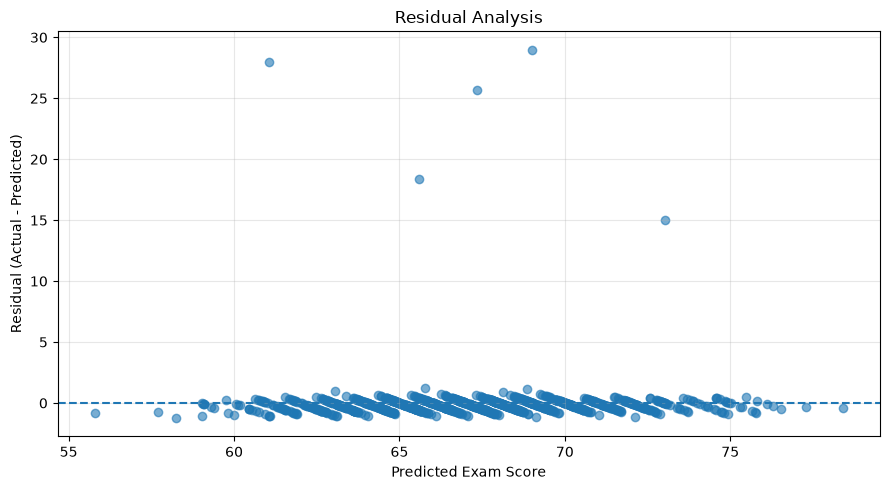

In [12]:
# 12. Residual plot

plt.figure(figsize=(9, 5))

plt.scatter(
    evaluation_df["predicted_score"],
    evaluation_df["residual"],
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Exam Score")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Analysis")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


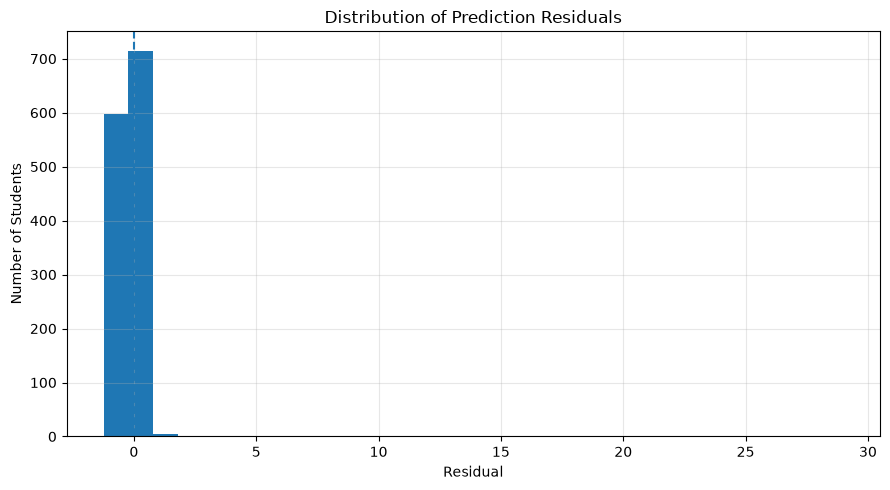

In [13]:
# 13. Residual distribution

plt.figure(figsize=(9, 5))

plt.hist(
    evaluation_df["residual"],
    bins=30
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residual")
plt.ylabel("Number of Students")
plt.title("Distribution of Prediction Residuals")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [14]:
# 14. Largest prediction errors

largest_errors = (
    evaluation_df
    .sort_values("absolute_error", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

display(largest_errors)


,actual_score,predicted_score,residual,absolute_error,squared_error,prediction_error_pct
0,98,69.017754,28.982246,28.982246,839.970599,29.573721
1,89,61.058265,27.941735,27.941735,780.740528,31.395207
2,93,67.344343,25.655657,25.655657,658.212749,27.586728
3,84,65.601544,18.398456,18.398456,338.503176,21.902924
4,88,73.024050,14.975950,14.975950,224.279077,17.018125
5,57,58.238561,-1.238561,1.238561,1.534033,2.172914
6,67,65.778789,1.221211,1.221211,1.491355,1.822702
7,70,68.856991,1.143009,1.143009,1.306469,1.632870
8,68,69.121141,-1.121141,1.121141,1.256958,1.648737
9,71,72.110524,-1.110524,1.110524,1.233263,1.564118


In [15]:
# 15. Final evaluation summary

final_evaluation = {
    "model": champion_name,
    "test_rows": int(len(y_test)),
    "test_rmse": float(rmse),
    "test_mae": float(mae),
    "test_r2": float(r2),
    "mean_residual": float(
        evaluation_df["residual"].mean()
    ),
    "median_absolute_error": float(
        evaluation_df["absolute_error"].median()
    ),
    "max_absolute_error": float(
        evaluation_df["absolute_error"].max()
    )
}

print("Final Evaluation Summary")
print("=" * 50)

for key, value in final_evaluation.items():
    print(f"{key}: {value}")


Final Evaluation Summary
model: LinearRegression
test_rows: 1322
test_rmse: 1.5224087707397842
test_mae: 0.4196458998132334
test_r2: 0.8247360799837526
mean_residual: -0.09752936251926084
median_absolute_error: 0.2901381315832765
max_absolute_error: 28.982246275108608


In [16]:
# 16. Save final evaluation artifacts

with open(
    METRICS_DIR / "final_model_evaluation.json",
    "w"
) as f:
    json.dump(final_evaluation, f, indent=4)

evaluation_df.to_csv(
    METRICS_DIR / "test_predictions.csv",
    index=False
)

joblib.dump(
    final_pipeline,
    MODELS_DIR / "edupredict_final_pipeline.joblib"
)

print("Saved:")
print("- outputs/metrics/final_model_evaluation.json")
print("- outputs/metrics/test_predictions.csv")
print("- models/edupredict_final_pipeline.joblib")


Saved:
- outputs/metrics/final_model_evaluation.json
- outputs/metrics/test_predictions.csv
- models/edupredict_final_pipeline.joblib


## Interpretation

The final test metrics should be reported exactly as produced by the notebook.

### Metric meanings

- **RMSE:** typical prediction error with extra penalty for larger errors.
- **MAE:** average absolute difference between actual and predicted exam scores.
- **R²:** proportion of target variance explained by the model relative to a mean-prediction baseline.

Do not claim that a model is clinically, educationally, or scientifically diagnostic. The system is a project-level **decision-support and prediction system** based on the supplied dataset.

The final model artifact saved here will be reused by the explainability notebook and later by the FastAPI/Streamlit application.


## Completion checklist

- [ ] Final model selected using validation data only.
- [ ] Test set evaluated only after model selection.
- [ ] Test RMSE generated.
- [ ] Test MAE generated.
- [ ] Test R² generated.
- [ ] Actual-vs-predicted plot generated.
- [ ] Residual plots generated.
- [ ] Largest errors inspected.
- [ ] Final evaluation JSON saved.
- [ ] Test predictions CSV saved.
- [ ] Final model pipeline saved.

**Next:** `09_explainability.ipynb`
